In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import plotly.express as px
import math



Load and re_arrange the firs dataset

In [4]:

# load first dataset 

first_diabetes_dataset = pd.read_csv("first_diabetes_dataset.csv")

print("Rows in second dataset:", len(first_diabetes_dataset))
first_diabetes_dataset['Diabetes'] = first_diabetes_dataset['Diabetes'].replace({2: 1})
first_diabetes_dataset.to_csv("first_diabetes_dataset.csv", index=False)
print(first_diabetes_dataset['Diabetes'].value_counts())


Rows in second dataset: 253680
Diabetes
0    213703
1     39977
Name: count, dtype: int64


Merge all data set

In [5]:
first_diabetes_dataset = pd.read_csv("first_diabetes_dataset.csv")
second_diabetes_dataset = pd.read_csv("second_diabetes_dataset.csv")
third_diabetes_dataset = pd.read_csv("third_diabetes_dataset.csv")

print("\nColumns in second dataset:")
print(second_diabetes_dataset.columns.tolist())
print("\nColumns in third dataset:")
print(third_diabetes_dataset.columns.tolist())


columns_first = set(first_diabetes_dataset.columns)
columns_second = set(second_diabetes_dataset.columns)
columns_third = set(third_diabetes_dataset.columns)


if columns_first==columns_second == columns_third:
   
    diabetes_dataset = pd.concat(
        [first_diabetes_dataset,second_diabetes_dataset, third_diabetes_dataset],
        ignore_index=True
    )
    print("Total rows after combining:", len(diabetes_dataset))

    diabetes_dataset.to_csv("diabetes_dataset.csv", index=False)
    print("Combined dataset saved as 'diabetes_dataset.csv'.")
else:
    print("Error: The columns in the datasets do not match and cannot be combined.")



Columns in second dataset:
['Diabetes', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'HvyAlcoholConsump', 'DiffWalk', 'Sex', 'Age']

Columns in third dataset:
['Diabetes', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'HvyAlcoholConsump', 'DiffWalk', 'Sex', 'Age']
Total rows after combining: 578052
Combined dataset saved as 'diabetes_dataset.csv'.


findinf the null value, change the null value to rounded mean

In [6]:
#check the null value if founded replace with rounded mean value
diabetes_dataset = pd.read_csv("diabetes_dataset.csv")
print("Dataset shape:", diabetes_dataset.shape)
print("Column names:", diabetes_dataset.columns.tolist())
finding_missing_values = diabetes_dataset.isnull().sum()

if finding_missing_values.sum() > 0:
    print("Missing values found. Filling with rounded mean values...")
    
    for column in diabetes_dataset.select_dtypes(include='number').columns:
        if diabetes_dataset[column].isnull().sum() > 0:
            mean_val = diabetes_dataset[column].mean()
            rounded_mean = 1 if mean_val >= 0.5 else 0
            diabetes_dataset[column].fillna(rounded_mean, inplace=True)
            print(f"→ Column '{column}': Filled missing values with {rounded_mean} (mean was {mean_val:.3f})")
            diabetes_dataset.to_csv("diabetes_dataset.csv", index=False)
            print("Cleaned dataset saved successfully.")
else:
    print("No missing values found.")





Dataset shape: (578052, 14)
Column names: ['Diabetes', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'HvyAlcoholConsump', 'DiffWalk', 'Sex', 'Age']
No missing values found.


grouping the bmi

In [7]:
#Grouping the BMI

diabetes_dataset = pd.read_csv("diabetes_dataset.csv")


bmi_labels = [
    'Underweight', 'Normal weight', 'Overweight',
    'Obese Class I', 'Obese Class II', 'Obese Class III'
]

#
if diabetes_dataset['BMI'].isin(bmi_labels).all():
    print("BMI is already categorized. Skipping binning step.")
else:
    
    diabetes_dataset['BMI'] = pd.to_numeric(diabetes_dataset['BMI'], errors='coerce')
    
   
    bmi_bins = [0, 18.5, 25, 30, 35, 40, float('inf')]
    
   
    diabetes_dataset['BMI'] = pd.cut(
        diabetes_dataset['BMI'],
        bins=bmi_bins,
        labels=bmi_labels,
        right=False,
        include_lowest=True
    )
    print("BMI has been categorized.")


diabetes_dataset.to_csv("diabetes_dataset.csv", index=False)
print("Dataset saved successfully.")

BMI has been categorized.
Dataset saved successfully.


In [8]:

print("total dataset:", len(diabetes_dataset))

count_diabetes_0 = (diabetes_dataset['Diabetes'] == 0).sum()
count_diabetes_1 = (diabetes_dataset['Diabetes'] == 1).sum()

print("Total rows with diabetes == 0:", count_diabetes_0)
print("Total rows with diabetes == 1:", count_diabetes_1)


total dataset: 578052
Total rows with diabetes == 0: 467383
Total rows with diabetes == 1: 110669


Checking is the all comoumn have right true and false value

In [9]:


numeric_columns = diabetes_dataset.select_dtypes(include=[np.number]).columns
exclude_cols = ['BMI', 'Age']
columns_to_check = [col for col in numeric_columns if col not in exclude_cols]


for column in columns_to_check:
    invalid_mask = ~diabetes_dataset[column].isin([0, 1])
    invalid_values = diabetes_dataset[column][invalid_mask]
    
    if not invalid_values.empty:
        print(f"\Invalid values found in column '{column}':")
        print(invalid_values)
        valid_mean = round(diabetes_dataset[column][~invalid_mask].mean())
        diabetes_dataset.loc[invalid_mask, column] = valid_mean
        
        print(f"→ Replaced invalid values with rounded mean: {valid_mean}")
    else:
        print(f"All values in column '{column}' are valid (0 or 1).")

All values in column 'Diabetes' are valid (0 or 1).

<>:11: SyntaxWarning: invalid escape sequence '\I'
<>:11: SyntaxWarning: invalid escape sequence '\I'
C:\Users\L E N O V O\AppData\Local\Temp\ipykernel_13096\1357958220.py:11: SyntaxWarning: invalid escape sequence '\I'
  print(f"\Invalid values found in column '{column}':")



All values in column 'HighBP' are valid (0 or 1).
All values in column 'HighChol' are valid (0 or 1).
All values in column 'CholCheck' are valid (0 or 1).
All values in column 'Smoker' are valid (0 or 1).
All values in column 'Stroke' are valid (0 or 1).
All values in column 'HeartDiseaseorAttack' are valid (0 or 1).
All values in column 'PhysActivity' are valid (0 or 1).
All values in column 'Fruits' are valid (0 or 1).
All values in column 'HvyAlcoholConsump' are valid (0 or 1).
All values in column 'DiffWalk' are valid (0 or 1).
All values in column 'Sex' are valid (0 or 1).


In [10]:
#data analysis
#Summary statistics
#Class Balance (Target Variable)
#Correlation Matrix
#Feature Distribution
# Cross-Analysis (Diabetes vs. Other Features)

Diabetes class distribution 

            Diabetes         HighBP       HighChol      CholCheck  \
count  578052.000000  578052.000000  578052.000000  578052.000000   
mean        0.191452       0.445444       0.436544       0.964209   
std         0.393444       0.497015       0.495957       0.185769   
min         0.000000       0.000000       0.000000       0.000000   
25%         0.000000       0.000000       0.000000       1.000000   
50%         0.000000       0.000000       0.000000       1.000000   
75%         0.000000       1.000000       1.000000       1.000000   
max         1.000000       1.000000       1.000000       1.000000   

              Smoker         Stroke  HeartDiseaseorAttack   PhysActivity  \
count  578052.000000  578052.000000         578052.000000  578052.000000   
mean        0.447095       0.043212              0.100744       0.750000   
std         0.497194       0.203335              0.300989       0.433013   
min         0.000000       0.000000              0.000000       0.000000  

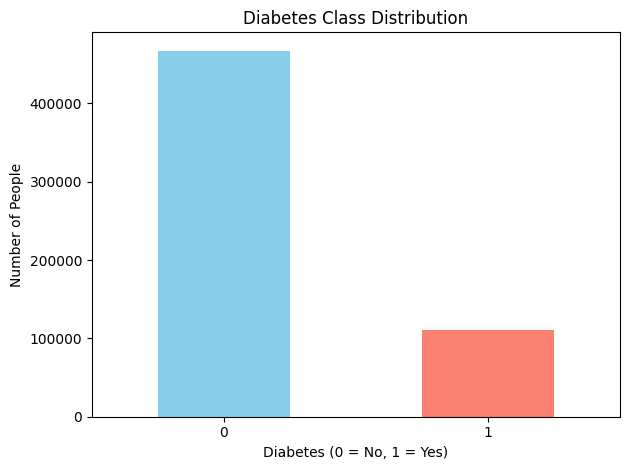

In [11]:
# Summary statistics
# Load the cleaned dataset
diabetes_dataset = pd.read_csv("diabetes_dataset.csv")
print(diabetes_dataset.describe())


# Print exact count of each class
print(diabetes_dataset['Diabetes'].value_counts())

# Plot exact counts (not proportions)
diabetes_dataset['Diabetes'].value_counts().plot(kind='bar', title='Diabetes Class Distribution', color=['skyblue', 'salmon'])
plt.xlabel('Diabetes (0 = No, 1 = Yes)')
plt.ylabel('Number of People')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Heatmap

Diabetes                 int64
HighBP                   int64
HighChol                 int64
CholCheck                int64
BMI                     object
Smoker                   int64
Stroke                   int64
HeartDiseaseorAttack     int64
PhysActivity             int64
Fruits                   int64
HvyAlcoholConsump        int64
DiffWalk                 int64
Sex                      int64
Age                      int64
dtype: object


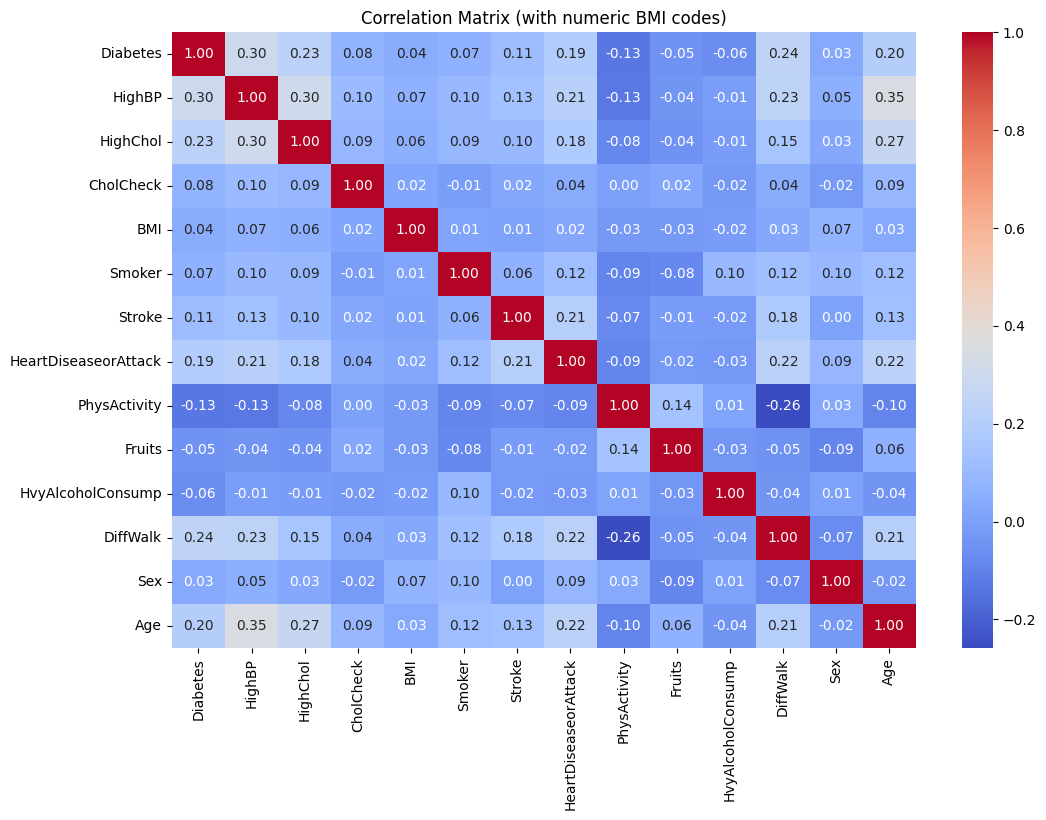

In [12]:

print(diabetes_dataset.dtypes)
diabetes_dataset['BMI'] = diabetes_dataset['BMI'].astype('category')
diabetes_dataset['BMI'] = diabetes_dataset['BMI'].cat.codes
numeric_data = diabetes_dataset.select_dtypes(include=['number'])

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix (with numeric BMI codes)')
plt.show()

heatmap in ploty express

In [13]:


# Step 1: Convert 'BMI' column to category and then to codes
diabetes_dataset['BMI'] = diabetes_dataset['BMI'].astype('category')
diabetes_dataset['BMI'] = diabetes_dataset['BMI'].cat.codes

# Step 2: Select numeric data and compute correlation
numeric_data = diabetes_dataset.select_dtypes(include=['number'])
corr_matrix = numeric_data.corr().round(2)

# Step 3: Convert the correlation matrix to long format
corr_long = corr_matrix.reset_index().melt(id_vars='index')
corr_long.columns = ['Feature1', 'Feature2', 'Correlation']

fig = px.imshow(
    corr_matrix,
    text_auto=True,
    color_continuous_scale='RdBu',
    zmin=-1,
    zmax=1,
    title='Correlation Matrix (with numeric BMI codes)'
)

fig.update_layout(width=800, height=600)
fig.show()

In [14]:
#Distribution of BMI


In [15]:
diabetes_dataset.describe()

,Diabetes,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,HvyAlcoholConsump,DiffWalk,Sex,Age
count,578052.000000,578052.000000,578052.000000,578052.000000,578052.000000,578052.000000,578052.000000,578052.000000,578052.000000,578052.000000,578052.000000,578052.000000,578052.000000,578052.000000
mean,0.191452,0.445444,0.436544,0.964209,2.084001,0.447095,0.043212,0.100744,0.750000,0.631509,0.054549,0.178558,0.442379,8.099617
std,0.393444,0.497015,0.495957,0.185769,1.700621,0.497194,0.203335,0.300989,0.433013,0.482396,0.227097,0.382982,0.496669,3.035618
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.750000,0.000000,0.000000,0.000000,0.000000,6.000000
50%,0.000000,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,8.000000
75%,0.000000,1.000000,1.000000,1.000000,4.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,10.000000
max,1.000000,1.000000,1.000000,1.000000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,13.000000


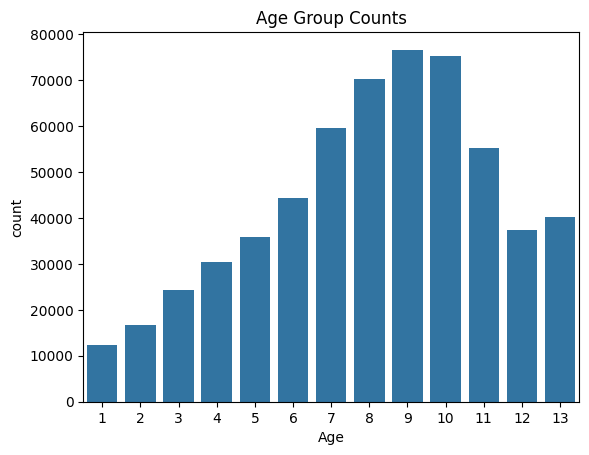

In [16]:
# Example: Count plot for Age
sns.countplot(data=diabetes_dataset, x='Age')
plt.title('Age Group Counts')
plt.show()

In [17]:
# # Diabetes vs HighBP
# sns.countplot(x='HighBP', hue='Diabetes', data=diabetes_dataset)
# plt.title('High Blood Pressure vs Diabetes')
# plt.show()

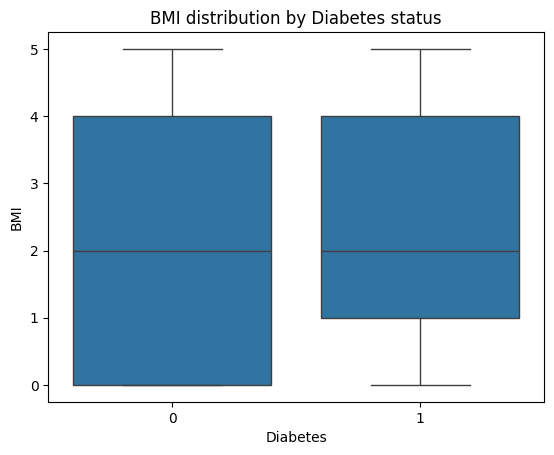

In [18]:


# # Example: Count plot for Age
# sns.countplot(data=diabetes_dataset, x='Age')
# plt.title('Age Group Counts')
# plt.show()

# # Cross-Analysis (Diabetes vs. Other Features)
# # Diabetes vs HighBP
# sns.countplot(x='HighBP', hue='Diabetes', data=diabetes_dataset)
# plt.title('High Blood Pressure vs Diabetes')
# plt.show()

# Diabetes vs BMI (Boxplot)
sns.boxplot(x='Diabetes', y='BMI', data=diabetes_dataset)
plt.title('BMI distribution by Diabetes status')
plt.show()

In [19]:
#model creation
#xgboost data model
#Random forest
#svm 


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE 
from collections import Counter

split the dataset

In [21]:
# Load and split data
X = diabetes_dataset.drop('Diabetes', axis=1)
y = diabetes_dataset['Diabetes']

# Split data (80% test, 20% train as in your original)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.80, random_state=42
)

use the oversampling to make the balance between zero and one

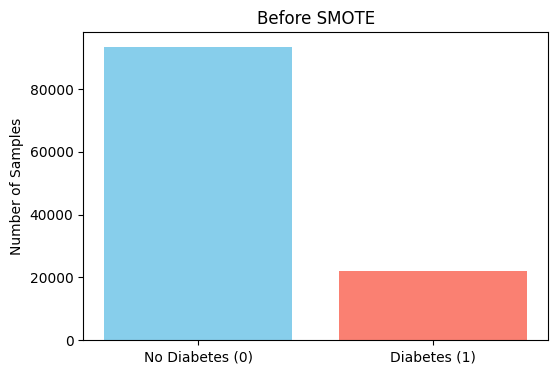

Class distribution after SMOTE:
Counter({1: 93416, 0: 93416})


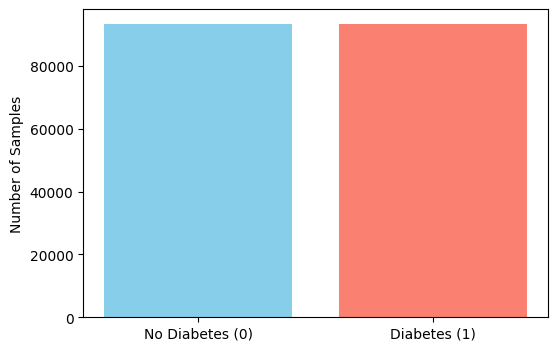

In [22]:
from imblearn.over_sampling import SMOTE
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Partial oversampling (50%)
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# Prepare list for results
results = []

def evaluate_model(name, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    result = {
        'Model': name,
        'Accuracy (%)': round(accuracy * 100, 2)
    }
    results.append(result)
    return result
# Before SMOTE plot
plt.figure(figsize=(6, 4))
plt.bar(['No Diabetes (0)', 'Diabetes (1)'], [Counter(y_train)[0], Counter(y_train)[1]], color=['skyblue', 'salmon'])
plt.title("Before SMOTE")
plt.ylabel("Number of Samples")
plt.show()

# Class distribution after SMOTE
print("Class distribution after SMOTE:")
print(Counter(y_train_balanced))

# After SMOTE plot
plt.figure(figsize=(6, 4))
plt.bar(['No Diabetes (0)', 'Diabetes (1)'], [Counter(y_train_balanced)[0], Counter(y_train_balanced)[1]], color=['skyblue', 'salmon'])

plt.ylabel("Number of Samples")
plt.show()

4 model and their output

c:\Users\L E N O V O\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning:

[15:51:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.




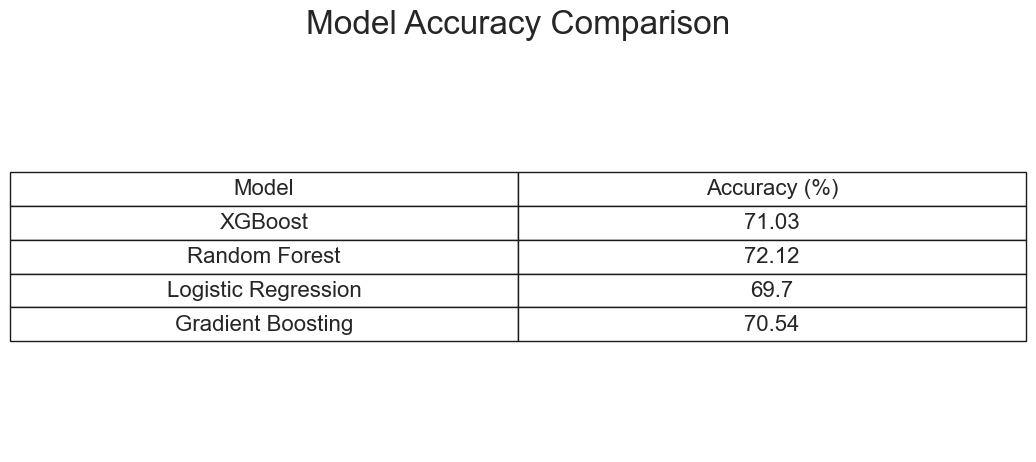

In [23]:
# Model 1: XGBoost
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train_balanced, y_train_balanced)
xgb_pred = xgb_model.predict(X_test)
evaluate_model("XGBoost", y_test, xgb_pred)

# Model 2: Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_balanced, y_train_balanced)
rf_pred = rf_model.predict(X_test)
evaluate_model("Random Forest", y_test, rf_pred)

# Model 3: Logistic Regression
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_balanced, y_train_balanced)
log_pred = log_model.predict(X_test)
evaluate_model("Logistic Regression", y_test, log_pred)

# Model 4: Gradient Boosting
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train_balanced, y_train_balanced)
gb_pred = gb_model.predict(X_test)
evaluate_model("Gradient Boosting", y_test, gb_pred)

# Convert results to DataFrame
df_results = pd.DataFrame(results)

# Plot as a table
sns.set(style="white", font_scale=1.6)
plt.figure(figsize=(12, 5))
table_plot = plt.table(cellText=df_results.values,
                       colLabels=df_results.columns,
                       loc='center',
                       cellLoc='center',
                       colLoc='center')

table_plot.scale(1.5, 2.0)
table_plot.auto_set_font_size(False)
table_plot.set_fontsize(16)

plt.axis('off')
plt.title('Model Accuracy Comparison', fontsize=24, pad=20)
plt.tight_layout()
plt.savefig('model_accuracy_table.png', dpi=300)
plt.show()

# Hyper Perameter Tuning

In [24]:
from sklearn.model_selection import RandomizedSearchCV
MAX_Random_Iteration = 20

In [25]:
# # X_test['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke',
# #        'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'HvyAlcoholConsump',
# #        'DiffWalk', 'Sex', 'Age']

# X_test = X_test.drop(columns=['CholCheck', 'Fruits', 'Smoker', 'Stroke'])
# X_train_balanced = X_train_balanced.drop(columns=['CholCheck', 'Fruits', 'Smoker', 'Stroke'])

### XGBoost Hyperparameter Tuning

In [26]:
# from sklearn.metrics import classification_report, confusion_matrix
# xgb_param_grid = {
#     'n_estimators': [100, 300, 500],
#     'learning_rate': [0.03, 0.05, 0.07],
#    'max_depth': [3, 4, 5, 6],
#     'subsample': [0.6, 0.8, 1.0],
#     'colsample_bytree': [0.6, 0.8, 1.0]
# }

# xgb_model = XGBClassifier(eval_metric='logloss', random_state=42)
# xgb_random = RandomizedSearchCV(estimator=xgb_model, param_distributions=xgb_param_grid,
#                                 n_iter=MAX_Random_Iteration, cv=3, verbose=0, n_jobs=-1, random_state=42)
# xgb_random.fit(X_train_balanced, y_train_balanced)
# xgb_best = xgb_random.best_estimator_
# xgb_pred = xgb_best.predict(X_test)
# res = evaluate_model("XGBoost Tuned", y_test, xgb_pred)
# print(res['Accuracy (%)']) 
# print(res)
# # print(classification_report(y_test, xgb_pred, digits=3))

### Random Forest Hyperparameter Tuning

In [27]:
# rf_param_grid = {
#     'n_estimators': [100, 300, 500],
#     'max_depth': [None, 10, 20, 30],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4],
#     'max_features': ['sqrt']
# }

# rf_random = RandomizedSearchCV(estimator=RandomForestClassifier(random_state=42),
#                                param_distributions=rf_param_grid,
#                                n_iter=MAX_Random_Iteration, cv=3, verbose=0, n_jobs=-1, random_state=42)
# rf_random.fit(X_train_balanced, y_train_balanced)
# rf_best = rf_random.best_estimator_
# rf_pred = rf_best.predict(X_test)
# res = evaluate_model("Random Forest Tuned", y_test, rf_pred)
# res[-1]

### Logistic Regression Hyperparameter Tuning

In [28]:
# log_param_grid = {
#     'C': [0.001, 0.01, 0.1, 1, 10, 100],
#     'penalty': ['l2'],
#     'solver': ['lbfgs', 'saga']
# }

# log_random = RandomizedSearchCV(estimator=LogisticRegression(max_iter=1000, random_state=42),
#                                 param_distributions=log_param_grid,
#                                 n_iter=10, cv=3, verbose=0, n_jobs=-1, random_state=42)
# log_random.fit(X_train_balanced, y_train_balanced)
# log_best = log_random.best_estimator_
# log_pred = log_best.predict(X_test)
# res = evaluate_model("Logistic Regression Tuned", y_test, log_pred)
# print(res['Accuracy (%)']) 
# print(res)

### Gradient Boosting Hyperparameter Tuning

In [29]:
# gb_param_grid = {
#     'n_estimators': [100, 300, 500],
#     'learning_rate': [0.01, 0.05, 0.1],
#     'max_depth': [3, 5, 7],
#     'subsample': [0.6, 0.8, 1.0]
# }

# gb_random = RandomizedSearchCV(estimator=GradientBoostingClassifier(random_state=42),
#                                param_distributions=gb_param_grid,
#                                n_iter=MAX_Random_Iteration, cv=3, verbose=0, n_jobs=-1, random_state=42)
# gb_random.fit(X_train_balanced, y_train_balanced)
# gb_best = gb_random.best_estimator_
# gb_pred = gb_best.predict(X_test)
# res = evaluate_model("Gradient Boosting Tuned", y_test, gb_pred)
# print(res['Accuracy (%)']) 
# print(res)

In [30]:
# # Assuming evaluate_model appends to 'results'
# df_results = pd.DataFrame(results)

# sns.set(style="white", font_scale=1.6)
# plt.figure(figsize=(12, 5))
# table_plot = plt.table(cellText=df_results.values,
#                        colLabels=df_results.columns,
#                        loc='center',
#                        cellLoc='center',
#                        colLoc='center')

# table_plot.scale(1.5, 2.0)
# table_plot.auto_set_font_size(False)
# table_plot.set_fontsize(16)

# plt.axis('off')
# plt.title('Tuned Model Accuracy Comparison', fontsize=24, pad=20)
# plt.tight_layout()
# plt.savefig('tuned_model_accuracy_table.png', dpi=300)
# plt.show()

kfold and early stoping


Model Accuracy Comparison (in %):
                   Model  Accuracy (%)
     Logistic Regression         81.32
           Random Forest         83.23
          SGD Classifier         80.85
XGBoost (Early Stopping)         82.74


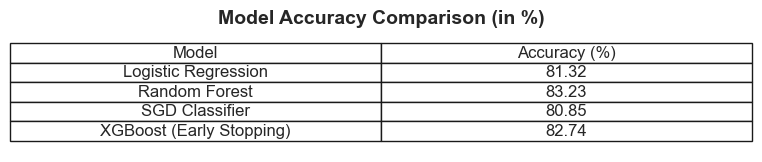

In [ ]:
import pandas as pd
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import joblib
df = pd.read_csv("diabetes_dataset.csv")

# Encode categorical variables
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

# Split features and target
X = df.drop("Diabetes", axis=1)
y = df["Diabetes"]

# Cross-validation setup
kf = KFold(n_splits=5, shuffle=True, random_state=42)
accuracy_results = {}

# Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_scores = cross_val_score(log_model, X, y, cv=kf, scoring='accuracy')
accuracy_results["Logistic Regression"] = log_scores.mean() * 100

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_scores = cross_val_score(rf_model, X, y, cv=kf, scoring='accuracy')
accuracy_results["Random Forest"] = rf_scores.mean() * 100

# SGD Classifier
sgd_model = SGDClassifier(max_iter=1000, tol=1e-3, random_state=42)
sgd_scores = cross_val_score(sgd_model, X, y, cv=kf, scoring='accuracy')
accuracy_results["SGD Classifier"] = sgd_scores.mean() * 100

# XGBoost
X_np = X.values
y_np = y.values
X_train, X_val, y_train, y_val = train_test_split(X_np, y_np, test_size=0.2, random_state=42)

dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_val, label=y_val)

params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'seed': 42
}

evals = [(dtrain, 'train'), (dval, 'eval')]

xgb_model = xgb.train(
    params,
    dtrain,
    num_boost_round=1000,
    evals=evals,
    early_stopping_rounds=10,
    verbose_eval=False
)

val_preds = (xgb_model.predict(dval) > 0.5).astype(int)
val_acc = accuracy_score(y_val, val_preds)
accuracy_results["XGBoost (Early Stopping)"] = val_acc * 100

# Create DataFrame from accuracy results
accuracy_df = pd.DataFrame(list(accuracy_results.items()), columns=["Model", "Accuracy (%)"])
accuracy_df["Accuracy (%)"] = accuracy_df["Accuracy (%)"].round(2)

# Print as text table
print("\nModel Accuracy Comparison (in %):")
print(accuracy_df.to_string(index=False))

# Plot fancy table using matplotlib
fig, ax = plt.subplots(figsize=(8, 2))  # Adjust figure size as needed
ax.axis('tight')
ax.axis('off')

# Create the table plot
table = ax.table(
    cellText=accuracy_df.values,
    colLabels=accuracy_df.columns,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.5)  # Adjust for better appearance

# Add title
plt.title("Model Accuracy Comparison (in %)", fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

rf_model_final = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',  # helps with imbalance
    random_state=42
)
rf_model_final.fit(X_train_balanced, y_train_balanced)
joblib.dump(rf_model_final, "random_forest_diabetes_model.pkl")


In [ ]:
import joblib
import pandas as pd

# Your input
input_data = {
    "HighBP": 1,
    "HighChol": 1,
    "CholCheck": 1,
    "BMI": 40,
    "Smoker": 1,
    "Stroke": 1,
    "HeartDiseaseorAttack": 1,
    "PhysActivity": 1,
    "Fruits": 1,
    "HvyAlcoholConsump": 0,
    "DiffWalk": 1,
    "Sex": 1,
    "Age": 9
}

# Load model
model = joblib.load("random_forest_diabetes_model.pkl")

# Predict
df = pd.DataFrame([input_data])
pred = model.predict(df)
print("Prediction:", pred[0])

Prediction: 1


c:\Users\L E N O V O\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning:

X has feature names, but RandomForestClassifier was fitted without feature names



using shap understand which features are influencing your diabetes prediction

In [ ]:
import shap


# Compute SHAP values on a sample
sample_data = X_train[:100]
explainer = shap.Explainer(xgb_model)
shap_values = explainer(sample_data)

# Create DataFrame of mean absolute SHAP values
mean_abs_shap = pd.DataFrame({
    'Feature': X.columns,
    'Mean |SHAP Value|': np.abs(shap_values.values).mean(axis=0)
})

# Sort and select top 10 features
top_features = mean_abs_shap.sort_values(by='Mean |SHAP Value|', ascending=False).head(10)

# Plot using Plotly Express
fig = px.bar(
    top_features,
    x='Mean |SHAP Value|',
    y='Feature',
    orientation='h',
    title='Top 10 Features Impacting Diabetes Prediction',
    color='Mean |SHAP Value|',
    color_continuous_scale='Blues'
)

fig.update_layout(yaxis=dict(autorange="reversed"))  # To match typical SHAP plot style
fig.show()

Confusion matrix or fandom forest

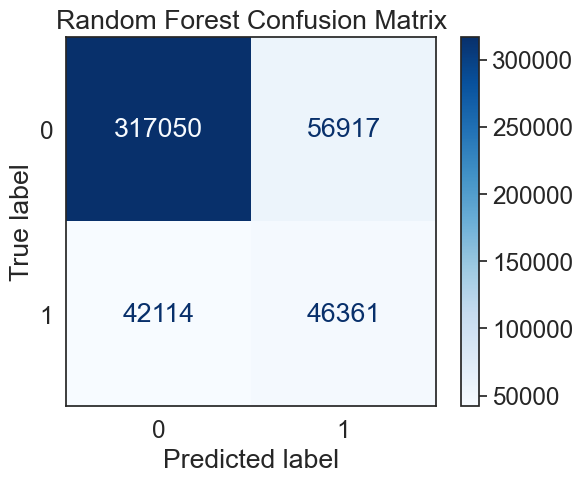

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc


rf_cm = confusion_matrix(y_test, rf_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=rf_cm, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
plt.title("Random Forest Confusion Matrix")
plt.show()

roc curved

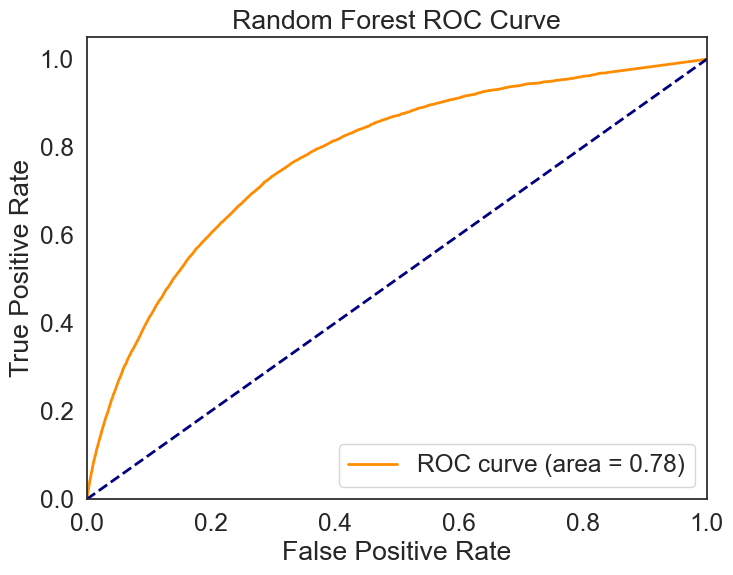

In [ ]:
# ROC Curve for Random Forest
# Get prediction probabilities for the positive class (1)
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_balanced, y_train_balanced)
rf_pred = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, rf_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest ROC Curve')
plt.legend(loc="lower right")
plt.show()